In [10]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from tqdm import tqdm
from pathlib import Path

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE_DIR   = Path('D:/ScanO-assign-Apaar')
DATA_DIR   = BASE_DIR / 'dataset'
TRAIN_DIR  = DATA_DIR / 'train'
OUT_DIR    = BASE_DIR / 'Exp3' / 'outputs'
SAMPLE_DIR = OUT_DIR / 'sample_outputs'

OUT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

METRICS_FILE = OUT_DIR / 'metrics.txt'

# Clear metrics file at start of training run
with open(METRICS_FILE, 'w') as f:
    f.write('=== DenseNet121 (pretrained on ImageNet) ===\n\n')

print('Paths initialised.')

Device: cpu
Paths initialised.


In [11]:
# ── Transforms ────────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(phase: int) -> dict:
    """
    Phase 1 : Resize + Normalize only (no augmentation)
    Phase 2+: Horizontal Flip + Rotation(±15°) + ColorJitter + Normalize
    Val/Test always uses Resize + Normalize only.
    """
    base_val = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),   # X-rays are grayscale
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    if phase == 1:
        train_tf = base_val
    else:  # Phase 2 & 3
        train_tf = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    return {'train': train_tf, 'val': base_val}


def make_dataloaders(phase: int, batch_size: int = 16):
    """
    Load ImageFolder from TRAIN_DIR, apply 85/15 stratified split,
    return (train_loader, val_loader, class_weights, full_dataset)
    """
    tfs = get_transforms(phase)

    # Load full train folder with train transforms first (to get labels)
    full_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tfs['train'])
    labels = [s[1] for s in full_dataset.samples]

    # 85/15 stratified split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))

    # Val subset uses val transforms — create separate dataset instance
    val_dataset = datasets.ImageFolder(root=str(TRAIN_DIR), transform=tfs['val'])

    train_subset = Subset(full_dataset, train_idx)
    val_subset   = Subset(val_dataset,  val_idx)

    # ── Class weights: total / (num_classes * class_count) ────────────────────
    train_labels = [labels[i] for i in train_idx]
    class_counts = np.bincount(train_labels)
    num_classes  = len(class_counts)
    total        = len(train_labels)
    weights      = total / (num_classes * class_counts)
    class_weights = torch.tensor(weights, dtype=torch.float32)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=False)
    val_loader   = DataLoader(val_subset,   batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=False)

    print(f'  Train: {len(train_subset)} | Val: {len(val_subset)}')
    print(f'  Class counts (train): {dict(zip(full_dataset.classes, class_counts))}')
    print(f'  Class weights: {dict(zip(full_dataset.classes, weights.round(4)))}')

    return train_loader, val_loader, class_weights, full_dataset


print('Dataset utilities ready.')

Dataset utilities ready.


In [12]:
def build_model(phase: int) -> nn.Module:
    """
    DenseNet121 with replaced classifier head.
    Phase 1 : backbone frozen, head = Linear(1024, 2)
    Phase 2 : backbone unfrozen, head = Linear(1024, 2)
    Phase 3 : backbone unfrozen, head = Dropout(0.3) + Linear(1024, 2)
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    # Phase 1 — freeze all backbone parameters
    if phase == 1:
        for param in model.features.parameters():
            param.requires_grad = False
    else:
        for param in model.features.parameters():
            param.requires_grad = True

    # Replace classifier head
    if phase in (1, 2):
        model.classifier = nn.Linear(1024, 2)
    else:  # Phase 3
        model.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(1024, 2)
        )

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f'  Trainable params: {trainable:,} / {total:,}')

    return model.to(DEVICE)


print('Model builder ready.')

Model builder ready.


In [13]:
import cv2
from PIL import Image


class GradCAM:
    """
    Grad-CAM hooked onto model.features.denseblock4 for DenseNet121.
    Expected activation shape: (B, 1024, 7, 7)
    """

    def __init__(self, model: nn.Module):
        self.model      = model
        self.gradients  = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        target_layer = self.model.features.denseblock4

        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        target_layer.register_forward_hook(forward_hook)
        target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor: torch.Tensor, class_idx: int) -> np.ndarray:
        """
        Returns a heatmap (H, W) numpy array in [0, 1].
        """
        self.model.zero_grad()
        output = self.model(input_tensor)               # (1, 2)
        score  = output[0, class_idx]
        score.backward()

        # Global average pool the gradients: (1024,)
        weights = self.gradients.mean(dim=(2, 3)).squeeze()  # (1024,)
        cams    = self.activations.squeeze()                 # (1024, 7, 7)

        # Weighted sum of activation maps
        cam = torch.relu((weights[:, None, None] * cams).sum(dim=0))  # (7, 7)
        cam = cam.numpy()

        # Normalise to [0, 1]
        if cam.max() > 0:
            cam = cam / cam.max()

        return cam


def overlay_gradcam(
    original_img: np.ndarray,
    cam: np.ndarray,
    alpha: float = 0.5
) -> np.ndarray:
    """
    Overlay Grad-CAM heatmap on original image.
    original_img : H×W×3 uint8 numpy array
    cam          : H×W float32 numpy array in [0, 1]
    Returns      : H×W×3 uint8 blended image
    """
    h, w = original_img.shape[:2]
    cam_resized = cv2.resize(cam, (w, h))
    heatmap = cv2.applyColorMap(
        (cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET
    )
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = (alpha * heatmap + (1 - alpha) * original_img).astype(np.uint8)
    return overlay


print('Grad-CAM ready.')

Grad-CAM ready.


In [14]:
def train_one_epoch(
    model, loader, optimizer, criterion
) -> tuple[float, float]:
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(loader, desc='  Train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(
    model, loader, criterion
) -> tuple[float, float, list, list]:
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='  Val  ', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs = model(imgs)
        loss    = criterion(outputs, labels)

        total_loss += loss.item() * imgs.size(0)
        preds      = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


print('Training loop ready.')

Training loop ready.


In [15]:
def append_metrics(
    phase: int,
    split: str,
    y_true: list,
    y_pred: list,
    class_names: list
):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm   = confusion_matrix(y_true, y_pred)

    lines = [
        f'--- Phase {phase} | {split} ---',
        f'Accuracy  : {acc:.4f}',
        f'Precision : {prec:.4f}',
        f'Recall    : {rec:.4f}',
        f'F1-Score  : {f1:.4f}',
        f'Confusion Matrix (rows=true, cols=pred):',
        f'Classes   : {class_names}',
        str(cm),
        ''
    ]
    with open(METRICS_FILE, 'a') as f:
        f.write('\n'.join(lines) + '\n')

    return acc, prec, rec, f1


def save_predictions_csv(
    phase: int,
    file_paths: list,
    y_true: list,
    y_pred: list,
    confidences: list,
    class_names: list
):
    df = pd.DataFrame({
        'filename'   : [os.path.basename(p) for p in file_paths],
        'filepath'   : file_paths,
        'true_label' : [class_names[t] for t in y_true],
        'pred_label' : [class_names[p] for p in y_pred],
        'confidence' : [round(c, 4) for c in confidences],
        'correct'    : [t == p for t, p in zip(y_true, y_pred)],
    })
    out_path = OUT_DIR / f'predictions_phase{phase}.csv'
    df.to_csv(out_path, index=False)
    print(f'  Saved: {out_path}')
    return df


def save_gradcam_samples(
    phase: int,
    model: nn.Module,
    predictions_df: pd.DataFrame,
    val_transform,
    class_names: list
):
    """
    Save 3 highest-confidence correct + 3 lowest-confidence / misclassified samples.
    Fallback: if fewer than 3 misclassified, use lowest-confidence correct predictions.
    Layout: Original | Grad-CAM heatmap (with colorbar) | Overlay
    """
    phase_dir = SAMPLE_DIR / f'phase{phase}'
    phase_dir.mkdir(parents=True, exist_ok=True)

    gradcam = GradCAM(model)
    model.eval()

    # ── Select samples ────────────────────────────────────────────────────────
    correct_df   = predictions_df[predictions_df['correct'] == True].copy()
    incorrect_df = predictions_df[predictions_df['correct'] == False].copy()

    top3_correct = correct_df.nlargest(3, 'confidence')

    if len(incorrect_df) >= 3:
        bottom3 = incorrect_df.nsmallest(3, 'confidence')
    else:
        n_needed = 3 - len(incorrect_df)
        fallback = correct_df.nsmallest(n_needed, 'confidence')
        bottom3  = pd.concat([incorrect_df, fallback])

    samples = [
        (top3_correct, 'correct'),
        (bottom3,      'wrong'),
    ]

    import matplotlib.cm as mplcm
    import matplotlib.colors as mcolors

    for subset_df, subset_tag in samples:
        for _, row in subset_df.iterrows():
            img_path = row['filepath']

            # ── Load original (grayscale → RGB for display) ───────────────────
            orig_pil  = Image.open(img_path).convert('RGB').resize((224, 224))
            orig      = np.array(orig_pil)                         # (224,224,3) uint8
            orig_gray = np.array(orig_pil.convert('L'))            # (224,224)   uint8

            # ── Grad-CAM tensor & generate ────────────────────────────────────
            tensor = val_transform(
                Image.open(img_path).convert('RGB')
            ).unsqueeze(0).to(DEVICE)
            tensor.requires_grad_(True)

            pred_idx  = class_names.index(row['pred_label'])
            cam       = gradcam.generate(tensor, pred_idx)         # (7,7) float [0,1]
            cam_224   = cv2.resize(cam, (224, 224))                # (224,224) float

            # ── Build heatmap array (JET, float [0,1]) for imshow ─────────────
            jet      = mplcm.get_cmap('jet')
            heatmap  = jet(cam_224)[:, :, :3]                     # (224,224,3) float [0,1]

            # ── Overlay: blend heatmap onto original ──────────────────────────
            alpha   = 0.5
            orig_f  = orig.astype(np.float32) / 255.0             # (224,224,3) float
            overlay = np.clip(alpha * heatmap + (1 - alpha) * orig_f, 0, 1)

            # ── 3-panel figure: Original | Grad-CAM | Overlay ─────────────────
            # Use gridspec so we can attach a colorbar to panel 1 only
            fig = plt.figure(figsize=(13, 4))
            gs  = fig.add_gridspec(
                1, 4,
                width_ratios=[1, 1, 0.06, 1],   # [orig, heatmap, cbar, overlay]
                wspace=0.08
            )
            ax0  = fig.add_subplot(gs[0])
            ax1  = fig.add_subplot(gs[1])
            axcb = fig.add_subplot(gs[2])
            ax2  = fig.add_subplot(gs[3])

            # Panel 0 — Original
            ax0.imshow(orig_gray, cmap='gray', vmin=0, vmax=255)
            ax0.set_title('Original', fontsize=11, pad=6)
            ax0.axis('off')

            # Panel 1 — Grad-CAM heatmap
            im = ax1.imshow(cam_224, cmap='jet', vmin=0, vmax=1)
            ax1.set_title('Grad-CAM', fontsize=11, pad=6)
            ax1.axis('off')

            # Colorbar attached to heatmap panel
            norm = mcolors.Normalize(vmin=0, vmax=1)
            sm   = plt.cm.ScalarMappable(cmap='jet', norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=axcb)
            cbar.set_ticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
            cbar.ax.tick_params(labelsize=8)

            # Panel 2 — Overlay
            ax2.imshow(overlay)
            ax2.set_title('Overlay', fontsize=11, pad=6)
            ax2.axis('off')

            # Filename as figure suptitle (small, below panels)
            fig.text(
                0.5, 0.01,
                f'True: {row["true_label"]}  |  Pred: {row["pred_label"]}  |  Conf: {row["confidence"]:.4f}  |  Phase {phase}',
                ha='center', fontsize=9, color='#444444'
            )

            plt.subplots_adjust(bottom=0.10)

            # Naming: val_gradcam_{correct|wrong}_true{label}_pred{label}_{index}.png
            import re as _re
            true_tag = row['true_label'].replace(' ', '')
            pred_tag = row['pred_label'].replace(' ', '')
            stem     = os.path.splitext(row['filename'])[0]
            m        = _re.search(r'(\d+)$', stem)
            idx_str  = m.group(1) if m else stem
            fname = phase_dir / f'val_gradcam_{subset_tag}_true{true_tag}_pred{pred_tag}_{idx_str}.png'
            plt.savefig(fname, dpi=120, bbox_inches='tight')
            plt.close()

    print(f'  Grad-CAM samples saved → {phase_dir}')


print('Utilities ready.')

Utilities ready.


In [16]:
@torch.no_grad()
def collect_val_predictions(
    model: nn.Module,
    val_idx: list,
    full_dataset,
    val_transform
) -> tuple[list, list, list, list]:
    """
    Run model on every val sample individually to capture filepath + confidence.
    Returns (file_paths, y_true, y_pred, confidences)
    """
    model.eval()
    file_paths, y_true, y_pred, confidences = [], [], [], []

    for idx in tqdm(val_idx, desc='  Collecting val preds', leave=False):
        img_path, label = full_dataset.samples[idx]
        img    = Image.open(img_path).convert('RGB')
        tensor = val_transform(img).unsqueeze(0).to(DEVICE)
        output = model(tensor)
        probs  = torch.softmax(output, dim=1).squeeze()
        pred   = probs.argmax().item()
        conf   = probs[pred].item()

        file_paths.append(img_path)
        y_true.append(label)
        y_pred.append(pred)
        confidences.append(conf)

    return file_paths, y_true, y_pred, confidences


print('Inference utility ready.')

Inference utility ready.


In [17]:
def run_phase(phase: int):
    print(f'\n{"="*60}')
    print(f'  PHASE {phase}')
    print(f'{"="*60}')
    t0 = time.time()

    # ── Data ──────────────────────────────────────────────────────────────────
    train_loader, val_loader, class_weights, full_dataset = make_dataloaders(phase)
    class_names = full_dataset.classes  # ['normal', 'pneumonia']

    # Recover val indices for per-sample inference
    labels = [s[1] for s in full_dataset.samples]
    sss    = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    train_idx, val_idx = next(sss.split(np.zeros(len(labels)), labels))

    val_transform = get_transforms(phase)['val']

    # ── Model ─────────────────────────────────────────────────────────────────
    model = build_model(phase)

    # ── Optimizer & Loss ──────────────────────────────────────────────────────
    lr = 1e-3 if phase in (1, 2) else 1e-4
    wd = 1e-4  if phase == 3      else 0.0
    ls = 0.1   if phase == 3      else 0.0

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=wd
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE),
        label_smoothing=ls
    )

    # ── Training loop with EarlyStopping ─────────────────────────────────────
    MAX_EPOCHS = 15
    PATIENCE   = 3

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_path  = OUT_DIR / f'best_model_phase{phase}.pth'
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, MAX_EPOCHS + 1):
        print(f'\n  Epoch {epoch}/{MAX_EPOCHS}')
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'  train_loss={train_loss:.4f}  train_acc={train_acc:.4f}')
        print(f'  val_loss  ={val_loss:.4f}  val_acc  ={val_acc:.4f}')

        # EarlyStopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f'  ✓ Best model saved (val_loss={best_val_loss:.4f})')
        else:
            patience_counter += 1
            print(f'  EarlyStopping patience {patience_counter}/{PATIENCE}')
            if patience_counter >= PATIENCE:
                print(f'  EarlyStopping triggered at epoch {epoch}.')
                break

    elapsed = (time.time() - t0) / 60
    print(f'\n  Training complete. Time: {elapsed:.1f} min')

    # ── Load best model for evaluation ────────────────────────────────────────
    model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

    # ── Collect val predictions ───────────────────────────────────────────────
    file_paths, y_true, y_pred, confidences = collect_val_predictions(
        model, val_idx, full_dataset, val_transform
    )

    # ── Save predictions CSV ──────────────────────────────────────────────────
    predictions_df = save_predictions_csv(
        phase, file_paths, y_true, y_pred, confidences, class_names
    )

    # ── Append metrics ────────────────────────────────────────────────────────
    acc, prec, rec, f1 = append_metrics(phase, 'Validation', y_true, y_pred, class_names)
    print(f'  Val Accuracy={acc:.4f}  F1={f1:.4f}')

    # ── Grad-CAM ──────────────────────────────────────────────────────────────
    print('  Generating Grad-CAM samples...')
    save_gradcam_samples(phase, model, predictions_df, val_transform, class_names)

    # ── Plot training curves ──────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs_range = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs_range, history['train_loss'], label='Train Loss')
    axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss')
    axes[0].set_title(f'Phase {phase} — Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    axes[1].plot(epochs_range, history['train_acc'], label='Train Acc')
    axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc')
    axes[1].set_title(f'Phase {phase} — Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    plt.tight_layout()
    curve_path = OUT_DIR / f'training_curves_phase{phase}.png'
    plt.savefig(curve_path, dpi=100)
    plt.show()
    plt.close()
    print(f'  Training curves saved → {curve_path}')

    return model, history


print('run_phase() ready.')

run_phase() ready.


### Phase 1 — Baseline Transfer Learning
**Backbone:** Frozen | **Augmentation:** None | **LR:** 1e-3


  PHASE 1
  Train: 544 | Val: 96
  Class counts (train): {'normal': np.int64(267), 'pneumonia': np.int64(277)}
  Class weights: {'normal': np.float64(1.0187), 'pneumonia': np.float64(0.9819)}
  Trainable params: 2,050 / 6,955,906

  Epoch 1/15


  train_loss=0.5843  train_acc=0.6949
  val_loss  =0.4837  val_acc  =0.7917
  ✓ Best model saved (val_loss=0.4837)

  Epoch 2/15


  train_loss=0.4086  train_acc=0.8493
  val_loss  =0.3459  val_acc  =0.8750
  ✓ Best model saved (val_loss=0.3459)

  Epoch 3/15


  train_loss=0.3678  train_acc=0.8474
  val_loss  =0.3199  val_acc  =0.8854
  ✓ Best model saved (val_loss=0.3199)

  Epoch 4/15


  train_loss=0.3450  train_acc=0.8658
  val_loss  =0.3168  val_acc  =0.8750
  ✓ Best model saved (val_loss=0.3168)

  Epoch 5/15


...

  train_loss=0.2665  train_acc=0.9191
  val_loss  =0.3302  val_acc  =0.8854
  EarlyStopping patience 2/3

  Epoch 9/15


  train_loss=0.2648  train_acc=0.9026
  val_loss  =0.3195  val_acc  =0.8854
  EarlyStopping patience 3/3
  EarlyStopping triggered at epoch 9.

  Training complete. Time: 21.4 min


  Saved: D:\ScanO-assign-Apaar\Exp3\outputs\predictions_phase1.csv
  Val Accuracy=0.8854  F1=0.8854
  Generating Grad-CAM samples...


C:\Users\apaar\AppData\Local\Temp\ipykernel_119560\1780463433.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet      = mplcm.get_cmap('jet')


  Grad-CAM samples saved → D:\ScanO-assign-Apaar\Exp3\outputs\sample_outputs\phase1


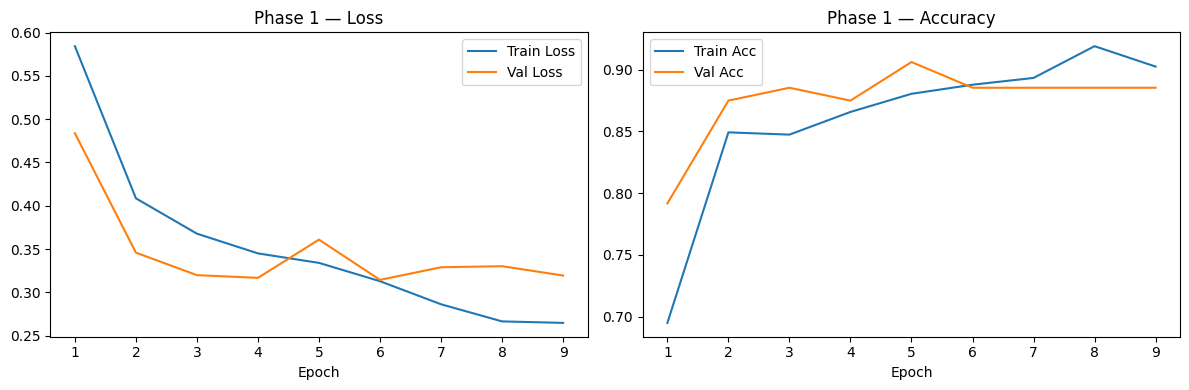

  Training curves saved → D:\ScanO-assign-Apaar\Exp3\outputs\training_curves_phase1.png


In [18]:
model_p1, history_p1 = run_phase(phase=1)

### Phase 2 — Augmentation Phase
**Backbone:** Unfrozen | **Augmentation:** Flip + Rotation + ColorJitter | **LR:** 1e-3


  PHASE 2
  Train: 544 | Val: 96
  Class counts (train): {'normal': np.int64(267), 'pneumonia': np.int64(277)}
  Class weights: {'normal': np.float64(1.0187), 'pneumonia': np.float64(0.9819)}
  Trainable params: 6,955,906 / 6,955,906

  Epoch 1/15


  train_loss=0.4636  train_acc=0.8382
  val_loss  =0.9454  val_acc  =0.6979
  ✓ Best model saved (val_loss=0.9454)

  Epoch 2/15


  train_loss=0.3812  train_acc=0.8676
  val_loss  =0.5118  val_acc  =0.8438
  ✓ Best model saved (val_loss=0.5118)

  Epoch 3/15


  train_loss=0.3350  train_acc=0.8824
  val_loss  =0.4877  val_acc  =0.8854
  ✓ Best model saved (val_loss=0.4877)

  Epoch 4/15


  train_loss=0.3131  train_acc=0.8897
  val_loss  =0.3588  val_acc  =0.8854
  ✓ Best model saved (val_loss=0.3588)

  Epoch 5/15


...

  train_loss=0.3053  train_acc=0.8934
  val_loss  =0.3762  val_acc  =0.9062
  EarlyStopping patience 2/3

  Epoch 7/15


  train_loss=0.2627  train_acc=0.9081
  val_loss  =2.0419  val_acc  =0.5104
  EarlyStopping patience 3/3
  EarlyStopping triggered at epoch 7.

  Training complete. Time: 23.4 min


  Saved: D:\ScanO-assign-Apaar\Exp3\outputs\predictions_phase2.csv
  Val Accuracy=0.8854  F1=0.8854
  Generating Grad-CAM samples...


C:\Users\apaar\AppData\Local\Temp\ipykernel_119560\1780463433.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet      = mplcm.get_cmap('jet')


  Grad-CAM samples saved → D:\ScanO-assign-Apaar\Exp3\outputs\sample_outputs\phase2


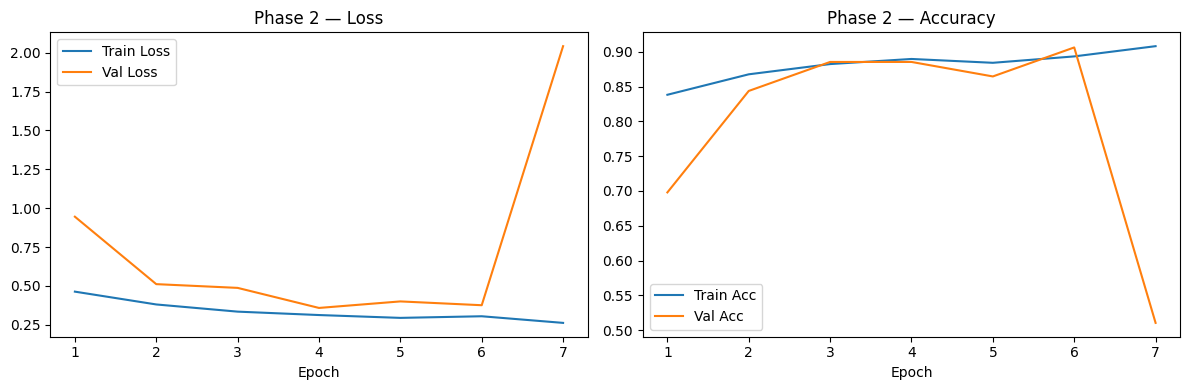

  Training curves saved → D:\ScanO-assign-Apaar\Exp3\outputs\training_curves_phase2.png


In [19]:
model_p2, history_p2 = run_phase(phase=2)

### Phase 3 — Regularized Fine-Tuning
**Backbone:** Unfrozen | **Augmentation:** Same as Phase 2 | **LR:** 1e-4 | **Dropout:** 0.3 | **WD:** 1e-4 | **Label Smoothing:** 0.1


  PHASE 3
  Train: 544 | Val: 96
  Class counts (train): {'normal': np.int64(267), 'pneumonia': np.int64(277)}
  Class weights: {'normal': np.float64(1.0187), 'pneumonia': np.float64(0.9819)}
  Trainable params: 6,955,906 / 6,955,906

  Epoch 1/15


  train_loss=0.4994  train_acc=0.8162
  val_loss  =0.4066  val_acc  =0.8958
  ✓ Best model saved (val_loss=0.4066)

  Epoch 2/15


  train_loss=0.3606  train_acc=0.9099
  val_loss  =0.4170  val_acc  =0.8958
  EarlyStopping patience 1/3

  Epoch 3/15


  train_loss=0.3461  train_acc=0.9338
  val_loss  =0.4183  val_acc  =0.9167
  EarlyStopping patience 2/3

  Epoch 4/15


  train_loss=0.3245  train_acc=0.9301
  val_loss  =0.4105  val_acc  =0.9062
  EarlyStopping patience 3/3
  EarlyStopping triggered at epoch 4.

  Training complete. Time: 11.1 min


  Saved: D:\ScanO-assign-Apaar\Exp3\outputs\predictions_phase3.csv
  Val Accuracy=0.8958  F1=0.8958
  Generating Grad-CAM samples...


C:\Users\apaar\AppData\Local\Temp\ipykernel_119560\1780463433.py:112: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet      = mplcm.get_cmap('jet')


  Grad-CAM samples saved → D:\ScanO-assign-Apaar\Exp3\outputs\sample_outputs\phase3


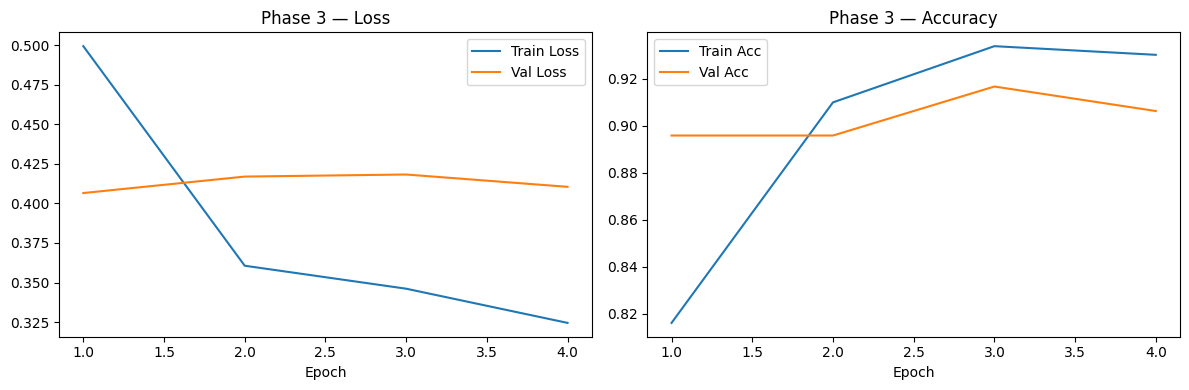

  Training curves saved → D:\ScanO-assign-Apaar\Exp3\outputs\training_curves_phase3.png


In [20]:
model_p3, history_p3 = run_phase(phase=3)

### Cross-Phase Comparison

In [21]:
# Read metrics.txt and print a clean summary
with open(METRICS_FILE, 'r') as f:
    print(f.read())

=== DenseNet121 (pretrained on ImageNet) ===

--- Phase 1 | Validation ---
Accuracy  : 0.8854
Precision : 0.8855
Recall    : 0.8854
F1-Score  : 0.8854
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[41  6]
 [ 5 44]]

--- Phase 2 | Validation ---
Accuracy  : 0.8854
Precision : 0.8871
Recall    : 0.8854
F1-Score  : 0.8854
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[43  4]
 [ 7 42]]

--- Phase 3 | Validation ---
Accuracy  : 0.8958
Precision : 0.8966
Recall    : 0.8958
F1-Score  : 0.8958
Confusion Matrix (rows=true, cols=pred):
Classes   : ['normal', 'pneumonia']
[[43  4]
 [ 6 43]]


